# Phase 2a-3. TME composition analysis

이 notebook의 목적은 TAM subtype별 세포 수/비율을 sample 단위로 계산하여, 종양 미세환경(TME)에서 C1QC+ TAM과 SPP1+ TAM의 구성 비율이 샘플마다 어떻게 다른지 확인하는 것이다

DEG가 gene-level 분석이라면, TME composition은 cell-level 분석이다

- DEG: 어떤 gene이 subtype을 구분하는가?
- TME composition: 어떤 cell subtype이 sample마다 얼마나 존재하는가?

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.paths import *

mac = sc.read_h5ad(MAC_PH2_H5AD)
print(mac)
print(mac.obs['tam_subtype'].value_counts())
print((mac.obs['tam_subtype'].value_counts(normalize=True) * 100).round(2))


AnnData object with n_obs × n_vars = 9567 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type', 'C1QC_score', 'SPP1_score', 'tam_subtype'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'deg_tam', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'tam_subtype_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
tam_subtype
Unknown                  4566
C1QC+ TAM    

## 1. 샘플별 TAM subtype composition 계산

전체 macrophage subset에서 subtype 비율을 보는 것도 중요하지만, 논문/임상적 질문에서는 sample 또는 patient 단위의 차이가 더 중요하다.

예:
- 어떤 sample은 C1QC+ TAM 비율이 높을 수 있음
- 어떤 sample은 SPP1+ TAM 비율이 높을 수 있음
- 어떤 sample은 macrophage subtype annotation이 거의 Unknown으로 남을 수 있음

In [2]:
required_cols = ['sample', 'tam_subtype']
missing_cols = [c for c in required_cols if c not in mac.obs.columns]
print('missing required columns:', missing_cols)

# composition - 암종별 * 서브타입별 세포 수 원본 테이블
composition = (
    mac.obs
    .groupby(['sample', 'tam_subtype'], observed=False)
    .size()
    .unstack(fill_value=0)
)

#composition_pct - composition 테이블을 백분율(비율)로 변환한 테이블
composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

display(composition.style.set_caption('TAM Subtype Cell Count by Cancer Type'))
display(composition_pct.round(1).style
        .set_caption('TAM Subtype Composition by Cancer Type')
        .format('{:.1f}%'))

missing required columns: []


tam_subtype,C1QC+ TAM,C1QC+ TAM (tentative),SPP1+ TAM,SPP1+ TAM (tentative),Unknown
sample,,,,,
0,220,88,24,98,359
1,231,135,28,106,353
2,97,41,16,50,146
3,122,59,19,63,176
4,0,0,0,1,232
5,0,1,0,0,323
6,0,7,0,6,318
7,4,3,0,4,21
8,5,5,0,4,12


tam_subtype,C1QC+ TAM,C1QC+ TAM (tentative),SPP1+ TAM,SPP1+ TAM (tentative),Unknown
sample,,,,,
0,27.9%,11.2%,3.0%,12.4%,45.5%
1,27.1%,15.8%,3.3%,12.4%,41.4%
2,27.7%,11.7%,4.6%,14.3%,41.7%
3,27.8%,13.4%,4.3%,14.4%,40.1%
4,0.0%,0.0%,0.0%,0.4%,99.6%
5,0.0%,0.3%,0.0%,0.0%,99.7%
6,0.0%,2.1%,0.0%,1.8%,96.1%
7,12.5%,9.4%,0.0%,12.5%,65.6%
8,19.2%,19.2%,0.0%,15.4%,46.2%


결과 그래프를 보면 이상한 점을 찾을 수 있다.

단순히 보면 Unknown이 과검출 되고 있다고 판단 된다는 것이다.
특히 sample 4, 5, 9, 13, 17, 22, 25는 거의 unknown이 99~100%에 달한다.

>> 여기서 나는 "annotation이 너무 과하게 되었나?" 하는 의문이 들었다.

이에따라 실제 subtype이 부여 된 개수를 세어 검증 해보겠다.

In [3]:
mac.obs["tam_subtype"].value_counts()

tam_subtype
Unknown                  4566
C1QC+ TAM                2346
C1QC+ TAM (tentative)    1471
SPP1+ TAM (tentative)     978
SPP1+ TAM                 206
Name: count, dtype: int64

In [4]:
pd.crosstab(
    mac.obs["sample"],
    mac.obs["cell_type"]
)

cell_type,Macrophage
sample,
0,789
1,853
2,350
3,439
4,233
5,324
6,331
7,32
8,26


>> 결론적으로는 Unknown이 너무 많은 것이 아니다.

위 두개의 수치를 보면 Macrophage의 총 합이 9567이며, Unknown은 그 중 4566이니까 Unknown은 전체의 약 47.7% 정도를 차지한다.
C1QC+ TAM, C1QC+ TAM (tentative)
SPP1+ TAM, SPP1+ TAM (tentative)의 세포 수를 모두 합치면 5001개이다.

즉, 전체 Macrophage 9567개 중  
- 5001개 (52.3%) -> C1QC/SPP1 관련 subtype으로 annotation되었고
- 4566개 (47.7%) -> 현재 기준에서 subtype이 부여되지 않은 상태이다.  
=> 따라서 sample 별 composition에서 Unknown 비율이 높게 나타난 것은 annotation 오류라기보다는 현재 분석이 C1QC+ TAM 및 SPP1+ TAM 중심으로 수행 되었기 때문이라고 해석 할 수 있다.

또한 C1QC+ TAM과 C1QC+ TAM (tentative), SPP1+ TAM과 SPP1+ TAM (tentative)는 DEG, Supplementary Table S3 signature, dotplot 결과에서 유사한 transcriptional program을 공유하는 것으로 나타났다.
그렇기 때문에 이후 TME composition 분석에서는 tentative subtype을 각각의 대표 subtype에 통합하여 최종 비율을 계산하는 방향으로 진행할 것 이다.

In [5]:
# tentative 통합
mac.obs["tam_subtype_final"] = (
    mac.obs["tam_subtype"]
    .replace({
        "C1QC+ TAM (tentative)": "C1QC+ TAM",
        "SPP1+ TAM (tentative)": "SPP1+ TAM",
    })
)

C:\Users\82108\AppData\Local\Temp\ipykernel_2084\2081233624.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace({


In [6]:
# composition 재계산
composition_final = (
    mac.obs
    .groupby(["sample", "tam_subtype_final"], observed=False)
    .size()
    .unstack(fill_value=0)
)

composition_pct_final = (
    composition_final
    .div(composition_final.sum(axis=1), axis=0)
    * 100
)

display(composition_pct_final.style.set_caption('TAM Subtype Cell Proportion by Cancer Type'))

tam_subtype_final,C1QC+ TAM,SPP1+ TAM,Unknown
sample,,,
0,39.036755,15.462611,45.500634
1,42.907386,15.709261,41.383353
2,39.428571,18.857143,41.714286
3,41.230068,18.678815,40.091116
4,0.000000,0.429185,99.570815
5,0.308642,0.000000,99.691358
6,2.114804,1.812689,96.072508
7,21.875000,12.500000,65.625000
8,38.461538,15.384615,46.153846


이전에는 `왜 Unknown이 많지?` 라는 의문에서 tentative 통합을 하고 composition을 재계산 하니 또 새로운 의문이 들었다.

>> 왜 특정 sample은 TAM subtype이 거의 안보일까?

- TAM이 없는 환자 인건지
- 그 샘플 자체가 immune infiltration이 적은 환자 인건지

알아보겠다.

In [7]:

pd.crosstab(
    mac.obs["sample"],
    mac.obs["cell_type"]
)

cell_type,Macrophage
sample,
0,789
1,853
2,350
3,439
4,233
5,324
6,331
7,32
8,26


In [8]:
adata = sc.read_h5ad(HUMAN_H5AD)
pd.crosstab(
    adata.obs["sample"],
    adata.obs["cell_type"]
)

cell_type,B cell,Cancer cell,Macrophage,T cell,Unknown
sample,,,,,
0,70,345,789,476,430
1,69,390,853,527,491
2,38,169,350,324,289
3,57,221,439,349,295
4,20,0,233,625,863
5,24,0,324,834,1032
6,21,0,331,881,1062
7,15,31,32,49,67
8,8,35,26,39,63


전체 data(adata)에서의 cell 비율과 macrophage(mac) 내에서의 cell 비율을 비교하니 흥미로운 결과가 보인다.

>> TAM annotation의 문제가 아니라 애초에 전체 세포의 조성이 다른 것으로 판단 된다.

예를 들어,

sample 9의 경우 전체에서 각 세포의 비율은
- Macrophage 232
- T cell 702
- Unknown 2788
전체: 3722
중 Macrophage 비율은 232 / 3722
즉, 6.2% 밖에 되지 않는다.

다른 발현이 적었던 샘플 13, 17번을 봐도 macrophage의 계산 해보았을때 비율이 10%를 넘지 못한다.  
그러므로 지금 발생한 현상은 단순히 ```Unknown subtype이 많다``` 가 아니라 ```그 샘플 자체에 Macrophage가 적다``` 에 가깝다는 판단을 내렸다.

전체 세포와 Macrophage 내부에서의 세포 구성을 시각화하여 비교해보겠다.

cell_type,B cell,Cancer cell,Macrophage,T cell,Unknown
sample,,,,,
0,3.3,16.4,37.4,22.6,20.4
1,3.0,16.7,36.6,22.6,21.1
2,3.2,14.4,29.9,27.7,24.7
3,4.2,16.2,32.3,25.6,21.7
4,1.1,0.0,13.4,35.9,49.6
5,1.1,0.0,14.6,37.7,46.6
6,0.9,0.0,14.4,38.4,46.3
7,7.7,16.0,16.5,25.3,34.5
8,4.7,20.5,15.2,22.8,36.8


<Axes: xlabel='sample'>

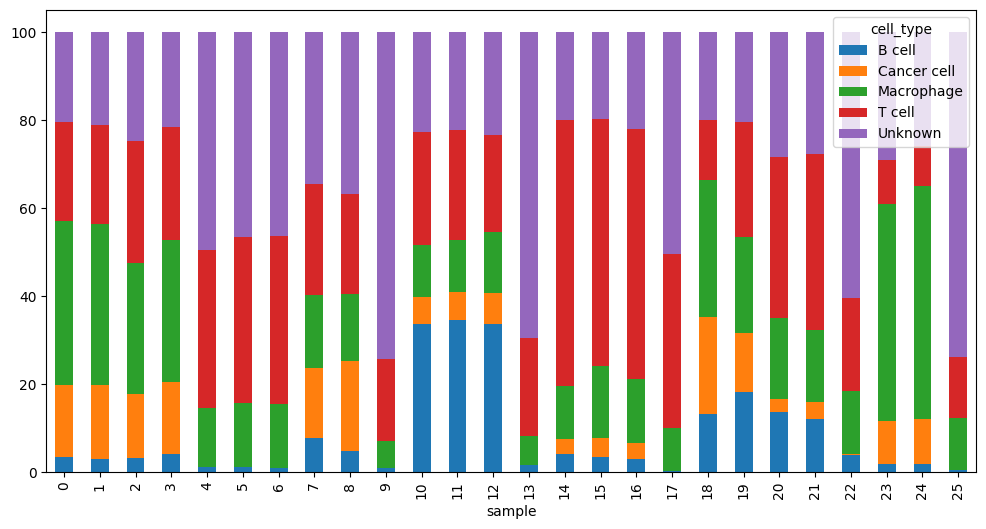

In [9]:
cell_comp = (
    adata.obs
    .groupby(["sample", "cell_type"], observed=False)
    .size()
    .unstack(fill_value=0)
)

cell_comp_pct = (
    cell_comp
    .div(cell_comp.sum(axis=1), axis=0)
    * 100
)

display(cell_comp_pct.round(1))

cell_comp_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

전체 TME 확인 결과:
- Sample 23, 24 - 거의 Macrophage dominant
- Sample 4 ~ 6 - 거의 T cell dominant
- Sample 10 ~ 12 - 거의 B cell dominant
- Sample 18 ~ 21 - T cell, Macrophage 둘 다 많은 mixed immune TME

확인 결과를 통해 알 수 있는 인사이트는 ```단순히 C1QC가 많다```가 아닌,
```같은 폐암 환자라도 TME 구성 자체가 매우 다르다.```
라는 것이다.

이는 폐암 환자 간 면역 미세환경의 높은 이질성(heterogenity)을 시사한다.

## 2. Stacked bar plot

Tentative subtype 을 대표 subtype에 통합한 뒤, sample별 C1QC+ TAM / SPP1+ TAM / Unknown 비율을 stacked bar plot으로 확인한다.

해석 포인트:
- C1QC+ TAM과 SPP1+ TAM이 함께 관찰되는 sample이 있는지
- sample별 TAM subtype composition이 균일한지 또는 heterogeneous한지
- macrophage-rich sample과 TAM subtype이 거의 관찰되지 않는 sample이 구분되는지

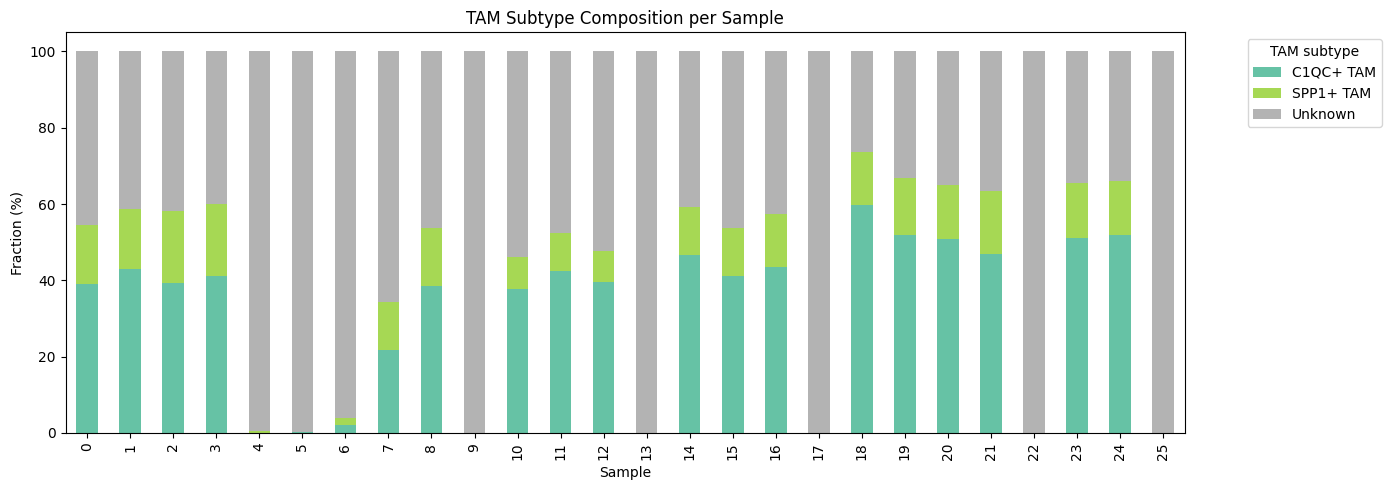

In [10]:
ax = composition_pct_final[
    ["C1QC+ TAM", "SPP1+ TAM", "Unknown"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 5),
    colormap="Set2"
)

plt.title("TAM Subtype Composition per Sample")
plt.ylabel("Fraction (%)")
plt.xlabel("Sample")
plt.xticks(rotation=90)
plt.legend(
    title="TAM subtype",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

초기 분석에서는 marker expression 기반으로 subtype을 annotation 했었는데
이후 Figure 2E, Figure S3, Supplementray Table S3 기반 검증 과정을 추가하면서 일부 cluster의 annotation이 수정되었으며, sample 별 composition pattern에도 변화가 발생했다

이는 scRNA-seq annotation 결과가 marker 선택 및 validation 전략에 영향을 받을 수 있음을 보여준다.

## 3. Interpretation note

현재 결과는 sample마다 TAM subtype composition이 다르다는 점을 보여준다.

다만 이 단계만으로 예후나 치료 반응을 직접 말할 수는 없다. 예후/치료 반응과 연결하려면 sample별 임상 정보 또는 treatment response label이 필요하다.

따라서 Phase 2a의 의미는 다음과 같다.

1. C1QC+ TAM / SPP1+ TAM subtype을 GSE127465에서 재현
2. DEG overlap으로 논문 marker signature 재현 확인
3. sample-level TAM composition 분석으로 Phase 3의 치료 반응 비교를 위한 기반 생성

In [11]:
mac.write(MAC_TME_H5AD)
print(f'저장 완료: {MAC_TME_H5AD}')

저장 완료: dataset\GSE127465_mac_phase2a_tme.h5ad


# Phase 2b. 다암종 확장 및 독립 검증

목표: pan-cancer 패턴 독립 검증

`다암종으로 확장하기에 앞서 추가해서 받아야 할 데이터`
GSE154763 — Set 1, 8개 암종 한번에 있는 데이터 셋, 이미 골수계 세포만 뽑혀있는 데이터라 전처리 부담 down
GSE131907 — LUAD, 내가 전처리 한 GSE127465랑 같은 폐암이라 직접 비교 가능

https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE154763
- LYM_metadata.csv.gz (19.3 Kb)
- LYM_normalized_expression.csv.gz (2.5 Mb)

https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE131907
- 미정
- 미정

파일 구조 확인
- 이미 normalized 된 데이터가 있어 QC 및 정규화 진행하지 않는다
- 하지만 raw data가 없어서 use_raw=True는 사용 불가능하다

다운로드 받은 LYM 파일은 csv 형식이기 때문에 h5ad파일로 파싱 해줘야 한다
그 전에 원본 csv 파일을 열어서 메타데이터 및 컬럼을 확인해줘야 한다 -> 샘플 정보 확인 차원

### LYM_META 확인결과
Major Cluster: 이미 cell type annotation 완료 되어있다 -> M06_Macro_ISG25같은 형식  
- cancer: LYM(림프종)
- patient: 환자ID
- tissue: T(tumor)
- UMAP1/2

=> 클러스터에 이미 Macrophage annotation이 되어있음

In [12]:
import pandas as pd

meta = pd.read_csv(LYM_META)
print(meta.shape)
print(meta.columns.tolist())
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(meta.head())

(615, 14)
['index', 'batch', 'patient', 'tissue', 'percent_hsp', 'percent_mito', 'n_genes', 'n_counts', 'MajorCluster', 'source', 'tech', 'cancer', 'UMAP1', 'UMAP2']
                 index  batch    patient tissue  percent_hsp  percent_mito  n_genes  n_counts     MajorCluster    source  tech cancer     UMAP1     UMAP2
0  AACACGTGTTTGGGCC-15     15  P20181123      T     0.006040           0.0     4789   29802.0  M02_cDC1_CLEC9A  ZhangLab  10X5    LYM  0.572999  3.933673
1  AACCGCGAGTTCGCAT-15     15  P20181123      T     0.003356           0.0     1641    5065.0  M06_Macro_ISG15  ZhangLab  10X5    LYM  5.801088  2.652734
2  AACTGGTAGCCACTAT-15     15  P20181123      T     0.000368           0.0      922    2716.0  M06_Macro_ISG15  ZhangLab  10X5    LYM  4.989789  4.353085
3  AAGGCAGTCGTCGTTC-15     15  P20181123      T     0.004203           0.0     1511    4759.0  M06_Macro_ISG15  ZhangLab  10X5    LYM  4.954624  1.894000
4  AAGGTTCAGATAGGAG-15     15  P20181123      T     0.016225    

LYM metadata는 615 cells x 14 column으로 구성되어있다.  
주요 컬럼은 patient, tissue, MajorCluster, cancer, UMAP1, UMAP2 등이다.  
MajorCluster 컬럼에는 M06_Macro_ISG15와 같이 이미 cell type/subtype annotation이 포함되어 있다.  
따라서 이 데이터는 raw clustering/annoation 대상이라기보다는 기존 annotation을 활용하여 macrophage/TAM 관련 cluster를 재검증하는 용도로 사용하는 것이 적절할 것이라 판단했다.

In [13]:
print(meta['MajorCluster'].value_counts())
print(meta['cancer'].value_counts())

MajorCluster
M06_Macro_ISG15    264
M04_Mono_CD14      141
M05_Mono_CD16      121
M07_Macro_C1QC      29
M03_cDC2_CD1C       26
M01_pDC_LILRA4      22
M02_cDC1_CLEC9A     12
Name: count, dtype: int64
cancer
LYM    615
Name: count, dtype: int64


MajorCluster 확인 결과, 이전 폐암 데이터와는 다르게 LYM 데이터에서는 M06_Macro_ISG15이 264 cells로 가장 많았고,  M07_Macro_C1QC는 29 cells로 상대적으로 적게 관찰되었다.  

해당 결과값으로 알 수 있는 것
- LYM 데이터는 총 615 cells이며, 전부 lymphoma(LYM) 데이터이다.
- MajorCluster는 이미 myeloid 계열 annotation이 포함되어있다.
- macrophage 관련 cluster는 M06_Macro_ISG15와 M07_Macro_C1QC 두 개가 존재한다.
- SPP1+ TAM은 별도 cluster로 제공되지 않았기 때문에 marker expression 또는 score 기반으로 추가 확인이 필요하다.

expression matrix 불러와서 AnnData로 merge 작업 진행

shape 로그를 찍어보니 현재 `LYM_normalized_expression` data는 cell이 row, gene이 column으로 데이터가 정상적으로 실려있기에 `.T`로 전치 해줄 필요가 없음
(5, 11283) -> `행x열`
- ['AACACGTGTTTGGGCC-15', 'AACCGCGAGTTCGCAT-15', 'AACTGGTAGCCACTAT-15'] -> `cell barcord -15(batch/샘플번호)`
- ['FO538757.2', 'LINC00115', 'NOC2L'] -> `genes`

sparse 행렬 + float32 다운캐스팅으로 메모리 절약
- 기본값인 float64 대신 float32 사용 -> 메모리 절반으로 감소
- csr_matrix로 희소행렬 변환 -> 0이 많은 scRNA-seq 데이터에 효율적

In [14]:
expr = pd.read_csv(LYM_NM, index_col=0, nrows=5)
print(expr.shape)
print(expr.index[:3].tolist())
print(expr.columns[:3].tolist())

(5, 11283)
['AACACGTGTTTGGGCC-15', 'AACCGCGAGTTCGCAT-15', 'AACTGGTAGCCACTAT-15']
['FO538757.2', 'LINC00115', 'NOC2L']


In [15]:
import anndata as ad
import scipy.sparse as sp

# 전체 로딩 후 전치
expr = pd.read_csv(LYM_NM, index_col=0)

print(expr.shape)  # (615, 11283) 나와야 함

# AnnData 생성
adata_lym = ad.AnnData(sp.csr_matrix(expr.values.astype('float32')))
adata_lym.obs_names = expr.index.tolist()
adata_lym.var_names = expr.columns.tolist()

# 메타데이터 붙이기
adata_lym.obs = meta.set_index('index').loc[adata_lym.obs_names].copy()

print(adata_lym)

adata_lym.uns['normalized'] = True
adata_lym.uns['source'] = 'GSE154763'
adata_lym.uns['cancer'] = 'LYM'

adata_lym.write_h5ad(LYM_H5AD)
print(f"Saved -> {LYM_H5AD}")

(615, 11283)
AnnData object with n_obs × n_vars = 615 × 11283
    obs: 'batch', 'patient', 'tissue', 'percent_hsp', 'percent_mito', 'n_genes', 'n_counts', 'MajorCluster', 'source', 'tech', 'cancer', 'UMAP1', 'UMAP2'
Saved -> dataset\phase2b\GSE154763_LYM.h5ad


같은 작업을 8개의 암종 모두 진행해야하기에 반복문을 실행해준다.

data merge 작업 시,
- outer join은 암종별 gene set 차이를 전부 보존하지만 어떤 암종에는 없는 gene이 0처럼 채워질 수 있어서 expression 비교나 score 계산에는 탁월하지 않다.
- 반대로 inner join은 공통 gene만 남기니 marker dotplot이나 score에는 더 안전하다.

In [16]:
from tqdm import tqdm

cancers = ['ESCA', 'KIDNEY', 'LYM', 'MYE', 'OV-FTC', 'PAAD', 'THCA', 'UCEC']

adata_list = []

for cancer in tqdm(cancers, desc="Loading"):
    expr_path = CSV_DIR / f'GSE154763_{cancer}_normalized_expression.csv.gz'
    meta_path = CSV_DIR / f'GSE154763_{cancer}_metadata.csv.gz'
    
    expr = pd.read_csv(expr_path, index_col=0)
    meta = pd.read_csv(meta_path)
    
    adata = ad.AnnData(sp.csr_matrix(expr.values.astype('float32')))
    adata.obs_names = expr.index.tolist()
    adata.var_names = expr.columns.tolist()
    adata.obs = meta.set_index('index').loc[adata.obs_names].copy()
    
    adata_list.append(adata)
    del expr

# all merge - outer join: composition / metadata 기반 분석용
adata_all_outer = sc.concat(adata_list, join='outer', index_unique='-')
print(adata_all_outer)

# all merge - inner join: dotplot / score / DEG 기반 분석용
adata_all_inner = sc.concat(adata_list, join='inner', index_unique='-')
print(adata_all_inner)

adata_all_outer.write_h5ad(ALL_OUTER_H5AD)
adata_all_inner.write_h5ad(ALL_INNER_H5AD)
print('저장 완료')

Loading: 100%|██████████| 8/8 [03:57<00:00, 29.71s/it]


AnnData object with n_obs × n_vars = 65698 × 18486
    obs: 'percent_mito', 'n_counts', 'percent_hsp', 'barcode', 'batch', 'library_id', 'cancer', 'patient', 'tissue', 'n_genes', 'MajorCluster', 'source', 'tech', 'UMAP1', 'UMAP2'
AnnData object with n_obs × n_vars = 65698 × 11102
    obs: 'percent_mito', 'n_counts', 'percent_hsp', 'batch', 'cancer', 'patient', 'tissue', 'n_genes', 'MajorCluster', 'source', 'tech', 'UMAP1', 'UMAP2'
저장 완료


In [ ]:
# 유전자 손실 확인

print(f"outer: {adata_all_outer.shape}")  # 전체 유전자
print(f"inner: {adata_all_inner.shape}")  # 공통 유전자
print(f"유전자 손실: {adata_all_outer.shape[1] - adata_all_inner.shape[1]}개")

In [ ]:
print(adata_all_outer.obs['cancer'].value_counts())
print(adata_all_outer.obs['MajorCluster'].value_counts())

cancer
KIDNEY    28930
UCEC       8808
ESCA       7673
MYE        7619
THCA       5312
OV-FTC     3888
PAAD       2853
LYM         615
Name: count, dtype: int64
MajorCluster
M07_Mono_CD16        11093
M06_Mono_CD14         9058
M04_cDC2_CD1C         7702
M09_Macro_C1QC        3953
M08_Macro_NLRP3       3903
M01_Mast_KIT          3868
M11_Macro_C1QC        2401
M09_Macro_IL1B        2363
M05_Mono_CD14         2321
M10_Macro_GPNMB       2264
M12_Macro_LYVE1       2202
M08_Macro_SPP1        1709
M06_Mono_CD14CD16     1608
M10_Macro_C1QC        1544
M08_Macro_FN1         1319
M11_Macro_LYVE1       1217
M13_Macro_INHBA       1100
M10_Macro_SPP1        1072
M09_Macro_INHBA        947
M05_cDC3_LAMP3         734
M02_pDC_LILRA4         675
M03_cDC1_CLEC9A        619
M09_Macro_SPP1         498
M03_cDC2_CD1C          340
M09_Macro_ISG15        318
M06_Macro_ISG15        264
M11_Macro_ISG15        144
M04_Mono_CD14          141
M05_Mono_CD16          121
M01_pDC_LILRA4         111
M02_cDC1_CLEC9A 

In [20]:
# Macrophage만 추출
adata_all = sc.read_h5ad(ALL_OUTER_H5AD)
mac_clusters = adata_all.obs['MajorCluster'].value_counts()
mac_only = mac_clusters[mac_clusters.index.str.contains('Macro')]
print(mac_only)

MajorCluster
M09_Macro_C1QC     3953
M08_Macro_NLRP3    3903
M11_Macro_C1QC     2401
M09_Macro_IL1B     2363
M10_Macro_GPNMB    2264
M12_Macro_LYVE1    2202
M08_Macro_SPP1     1709
M10_Macro_C1QC     1544
M08_Macro_FN1      1319
M11_Macro_LYVE1    1217
M13_Macro_INHBA    1100
M10_Macro_SPP1     1072
M09_Macro_INHBA     947
M09_Macro_SPP1      498
M09_Macro_ISG15     318
M06_Macro_ISG15     264
M11_Macro_ISG15     144
M07_Macro_C1QC       29
Name: count, dtype: int64


In [21]:
def map_tam_subtype(cluster):
    if 'C1QC' in cluster:
        return 'C1QC+ TAM'
    elif 'SPP1' in cluster:
        return 'SPP1+ TAM'
    elif 'ISG15' in cluster:
        return 'ISG15+ TAM'
    else:
        return 'Other Macrophage'
    
adata_mac = adata_all[adata_all.obs['MajorCluster'].str.contains('Macro', case=False, na=False)].copy()
adata_mac.obs['tam_subtype'] = adata_mac.obs['MajorCluster'].apply(map_tam_subtype)

print(adata_mac.obs['tam_subtype'].value_counts())

tam_subtype
Other Macrophage    15315
C1QC+ TAM            7927
SPP1+ TAM            3279
ISG15+ TAM            726
Name: count, dtype: int64


### observed = True 옵션
groupby 할 때 실제로 데이터에 존재하는 조합만 집계 하겠다는 것

예를들어 cancer가 KIDNEY, LYM이고 tam_subtype이 C1QC+, SPP1+, ISG15, Other이라면 이론적으로 가능한 조합은 2*4=8개다  
하지만 LYM에 ISG15+가 없을 수도 있다  
그때 observed = False (default)라면  
```LYM / ISG15+ TAM -> 0 없어도 행을 만들어 줌```  
근데 만약 observed = True 라면  
```LYM / ISG15+ TAM -> 아예 행 자체가 없음```

scRNA-seq에서는 observed를 True로 두고 사용해야하는 이유이다  
실제로 없는 조합을 0으로 채운다면 fill_value=0이 처리해주니까 observed = True로 실제 있는 것만 집계하고 unstack할 때 빈칸은 0으로 채울 수 있다

# B. Marker score-based subtype tendency

Macrophage cluster는 MajorCluster annotation에서 'Macro'가 포함된 cluster만 추출하였다.  
이후 C1QC, SPP1, ISG15가 cluster 이름에 명시된 경우에만 각각 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM으로 매핑하였다.  
그 외 NLRP3, IL1B, GPNMB, LYVE1, FN1, INHBA macrophage 등은 임의로 특정 TAM subtype에 병합하지 않고 Other Macrophage로 유지하였다.  

이는 기존 annotation을 과해석하지 않기 위한 방법이다.  
다만 Other Macrophage의 비중이 크기 때문에, 이후 marker score 기반 분석을 통해 이들 cluster가 C1QC-like, SPP1-like, ISG15-like 발현 경향을 보이는지 추가 확인하였다.  

>> 추후 B는 코드 상, A가 끝난 이후 새로운 insight로 순서를 수정할 것 이다.

기존 annotation에서 C1QC, SPP1, ISG15라는 이름이 명시된 macrophage cluster만 논문 subtype 축에 매핑했고 그 외 macrophage cluster는 임의로 병합하지 않고 Other Macrophage로 보존했다.  
하지만 Other Macrophage가 과반수라는 점과 각각 그 자체도 크게 관찰 된 것을 보아 Other가 어떤 macrophage인지 알고 싶어졌다.

그리하여, Other 내부 composition을 따로 확인 해보았다.  

### Other 내부 composition 따로 확인

해당 작업은 Other가 단순히 많다가 아니라 Other가 어떤 macrophage들인지 설명가능하게하는 근거이다.

In [22]:
other_mac = adata_mac[adata_mac.obs['tam_subtype'] == 'Other Macrophage'].copy()

print(other_mac.obs['MajorCluster'].value_counts())

other_counts = other_mac.obs['MajorCluster'].value_counts()
other_ratio = other_counts / other_counts.sum() * 100

other_summary = pd.DataFrame({
    'n_cells': other_counts,
    'percent_in_other': other_ratio
})

display(other_summary)

MajorCluster
M08_Macro_NLRP3    3903
M09_Macro_IL1B     2363
M10_Macro_GPNMB    2264
M12_Macro_LYVE1    2202
M08_Macro_FN1      1319
M11_Macro_LYVE1    1217
M13_Macro_INHBA    1100
M09_Macro_INHBA     947
Name: count, dtype: int64


,n_cells,percent_in_other
MajorCluster,,
M08_Macro_NLRP3,3903,25.484819
M09_Macro_IL1B,2363,15.429318
M10_Macro_GPNMB,2264,14.782893
M12_Macro_LYVE1,2202,14.378061
M08_Macro_FN1,1319,8.612471
M11_Macro_LYVE1,1217,7.946458
M13_Macro_INHBA,1100,7.182501
M09_Macro_INHBA,947,6.183480


Other macrophage 내부를 확인한 결과, 대부분은 단순한 미분류 세포가 아니라 NLRP3, IL1B, GPNMB, LYVE1, FN1, INHBA 등으로 annotation된 distinct macrophage states였다.  

따라서 이들을 C1QC/SPP1/ISG15 subtype으로 강제 병합하지 않고 Other Macrophage로 유지하는 것이 타당하다.  
다만 GPNMB macrophage는 SPP1-associated marker를 포함하고 있어, 이후 SPP1_score 기반으로 SPP1-like TAM 여부를 추가 확인할 필요가 있다.  

marker score 기반 분석을 통해 Other Macrophage 중 SPP1-like 또는 C1QC-like expression pattern을 보이는 cluster가 있는지 추가 평가하였다.

### Cancer 별 subtype 비율 보기

pan-cancer 검증이면 전체 count로만 판단하기엔 부족하다.  
암종별로 C1QC / SPP1 / ISG15 / Other 비율을 봐야한다고 판단하여 확인을 진행해보았다.

In [23]:
tam_by_cancer = pd.crosstab(
    adata_mac.obs['cancer'],
    adata_mac.obs['tam_subtype']
)

display(tam_by_cancer)

# 비율로 보기
tam_by_cancer_ratio = pd.crosstab(
    adata_mac.obs['cancer'],
    adata_mac.obs['tam_subtype'],
    normalize='index'
) * 100

display(tam_by_cancer_ratio.round(2))

tam_subtype,C1QC+ TAM,ISG15+ TAM,Other Macrophage,SPP1+ TAM
cancer,,,,
ESCA,1101,0,3724,0
KIDNEY,1536,0,7260,0
LYM,29,264,0,0
MYE,1005,0,151,0
OV-FTC,1925,0,0,1353
PAAD,1023,0,0,356
THCA,443,144,2241,498
UCEC,865,318,1939,1072


tam_subtype,C1QC+ TAM,ISG15+ TAM,Other Macrophage,SPP1+ TAM
cancer,,,,
ESCA,22.82,0.00,77.18,0.00
KIDNEY,17.46,0.00,82.54,0.00
LYM,9.90,90.10,0.00,0.00
MYE,86.94,0.00,13.06,0.00
OV-FTC,58.72,0.00,0.00,41.28
PAAD,74.18,0.00,0.00,25.82
THCA,13.32,4.33,67.38,14.97
UCEC,20.62,7.58,46.23,25.56


### 4. marker score로 Other가 어디에 가까운지 확인

문자열 annotation만으로는 각각의 subtype들이 SPP1-like인지, C1QC-like인지 독립 state인지 알 수 없기 때문에 marker score을 계산하여 정량적 수치 결과로 확인한다.

In [24]:
c1qc_genes = ['C1QA', 'C1QB', 'C1QC', 'APOC1']
spp1_genes = ['SPP1', 'GPNMB', 'CTSD', 'MRC1', 'CD63']
isg15_genes = ['ISG15', 'CXCL10', 'GBP1']

def filter_genes(adata, genes):
    return [g for g in genes if g in adata.var_names]

sc.tl.score_genes(
    adata_mac,
    gene_list=filter_genes(adata_mac, c1qc_genes),
    score_name='C1QC_score'
)

sc.tl.score_genes(
    adata_mac,
    gene_list=filter_genes(adata_mac, spp1_genes),
    score_name='SPP1_score'
)

sc.tl.score_genes(
    adata_mac,
    gene_list=filter_genes(adata_mac, isg15_genes),
    score_name='ISG15_score'
)

score_summary = adata_mac.obs.groupby('MajorCluster')[
    ['C1QC_score', 'SPP1_score', 'ISG15_score']
].mean()

display(score_summary.sort_values('SPP1_score', ascending=False))

C:\Users\82108\AppData\Local\Temp\ipykernel_2084\2458045692.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_summary = adata_mac.obs.groupby('MajorCluster')[


,C1QC_score,SPP1_score,ISG15_score
MajorCluster,,,
M08_Macro_SPP1,0.754657,0.926285,-0.056649
M07_Macro_C1QC,2.212909,0.836427,0.492541
M09_Macro_SPP1,-0.494923,0.827484,-0.104011
M10_Macro_SPP1,-0.554717,0.670064,0.073021
M09_Macro_C1QC,1.521986,0.546007,0.067366
M11_Macro_C1QC,1.624947,0.396928,-0.029374
M10_Macro_C1QC,1.387688,0.376013,0.256714
M10_Macro_GPNMB,1.620489,0.336418,-0.023057
M11_Macro_LYVE1,0.884790,0.234842,-0.132501


## score_genes() 계산 방식의 이해

>> marker 유전자 평균 발현에서 비슷한 발현 수준의 control gene평균을 뺀 값이기 때문에 0보다 작은 값이 나올 수 있다.

code에서 marker gene set이 기준(평균 값)인데 단순하게 `그 유전자들의 발현률 평균` 만 보는 것은 아니다.

gene set score
- 관심 marker gene들의 평균 발현량
- 비슷한 발현 수준을 가진 control gene 들의 평균 발현량

scanpy 공식 문서에서도 score_genes는 `주어진 gene set의 평균 발현에서 reference/control gene set의 평균 발현을 뺀 값` 이라고 설명되어있다. reference gene은 전체 gene pool에서 발현 수준 bin을 맞춰 무직위로 뽑는다.

### Q. 마이너스는 어떻게 나오는건가?

1. 예를 들어 SPP1_score를 계산할 때 gene set은 밑과 같다고 가정하자.  
`spp1_genes = ['SPP1', 'GPNMB', 'CTSD', 'MRC1', 'CD63']`  
2. 그러면 각 cell 마다 대략 이런 계산을 하게 된다.
SPP1_score
= mean (SPP1, GPNMB, CTSD, MRC1, CD63) - mean(control genes)
3. 그래서 값이 밑과 같이 나오게 된다.
- 양수 -> 이 marker set이 control gene 평균보다 높다
- 0근처 -> 특별히 높지 않다
- 음수 -> 이 marker set이 control gene 평균보다 낮다

즉, `마이너스 = 발현이 0` 이 아니다.
정확히는 비슷한 발현 수준의 배경 유전자들에 비해 marker set 발현이 낮다 라는 뜻이다.

In [ ]:
# 암종별 평균 score 비교
score_by_cancer = adata_mac.obs.groupby("cancer")[
    ["C1QC_score", "SPP1_score", "ISG15_score"]
].mean()

display(score_by_cancer.round(3))

C:\Users\82108\AppData\Local\Temp\ipykernel_2084\2290992112.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_by_cancer = adata_mac.obs.groupby("cancer")[


,C1QC_score,SPP1_score,ISG15_score
cancer,,,
ESCA,-0.003,0.098,0.122
KIDNEY,1.160,0.072,-0.070
LYM,-0.107,-0.191,1.293
MYE,0.896,0.081,0.130
OV-FTC,1.399,0.696,-0.016
PAAD,1.133,0.955,0.067
THCA,-0.008,-0.049,0.010
UCEC,-0.085,0.211,0.105


### Q. 각 암종의 macrophage population은 평균적으로 어떤 TAM marker program이 강한가?

C1QC: KIDNEY, OV-FTC, PAAD에서는 1을 넘을 정도로 확실하게 강하게 나타났지만 세가지 cell 중에서 음수로 측정된 것도 가장 많았다. 즉 특정 암종에 대하여 제한적인 발현량을 가지는 것 같다.  
SPP1: 가장 score가 높은 암이 PAAD로 0.955정도이다. Unknown으로 분류 된 암종들 중에 특별히 눈에 띌만한 결과는 아니다.  
ISG15: LYM만이 1점대 이상으로 높게 나타났다. 나머지는 거의 0.01대로 고르게 적게 분포한다.  

score avg만 본다면 cell-level의 분포가 보이지 않으니 boxplot이나 violin을 사용하여 추가 확인을 해보았다.  

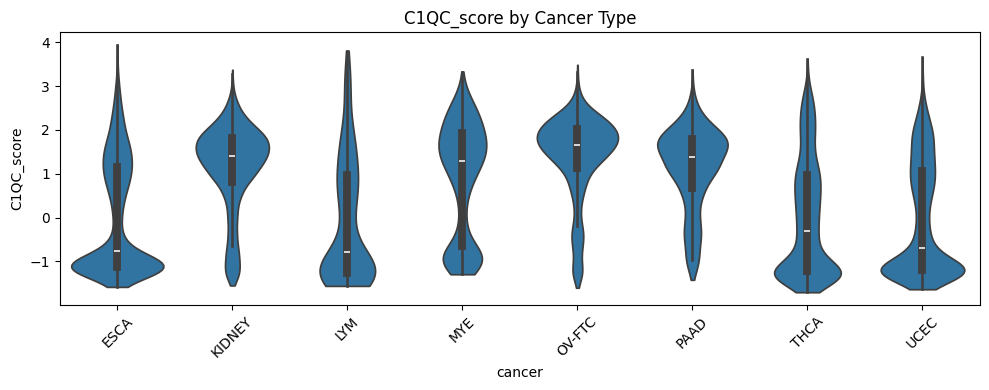

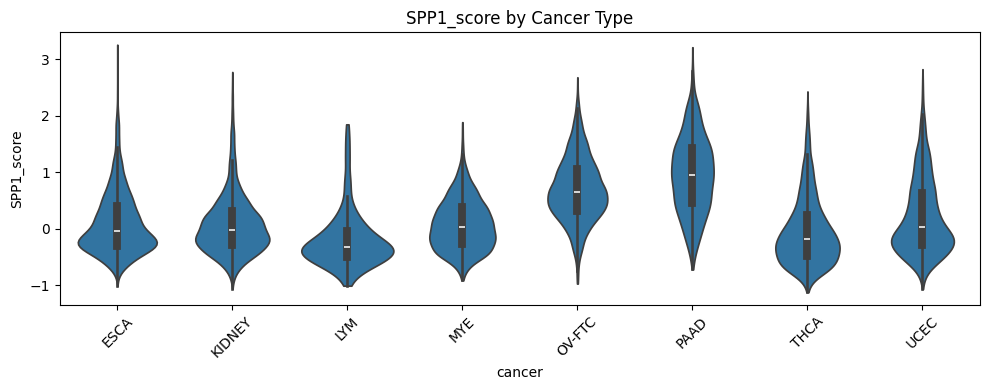

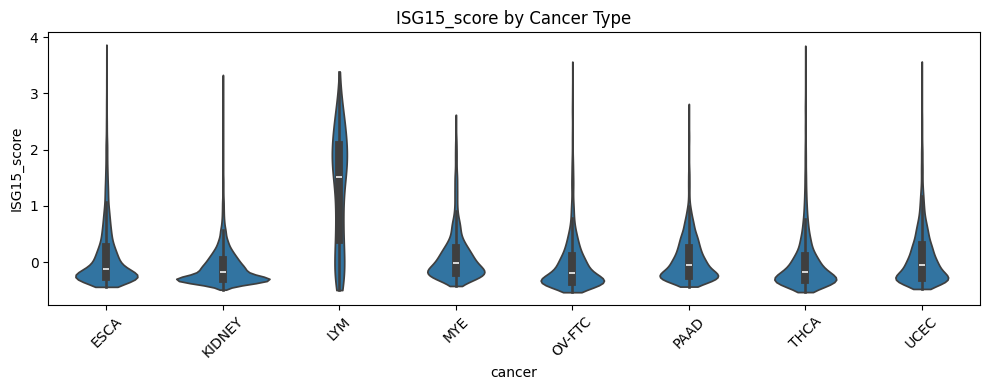

In [28]:
# 암종별 subtype score violin

import seaborn as sns
import matplotlib.pyplot as plt

score_cols = ["C1QC_score", "SPP1_score", "ISG15_score"]
    
for score in score_cols:
    plt.figure(figsize=(10, 4))
    sns.violinplot(
        data=adata_mac.obs,
        x="cancer",
        y=score,
        inner="box",
        cut=0
    )
    plt.title(f"{score} by Cancer Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### score based presence Upset

현재 Upset은 annotation 기반인데 score 기반 Upset을 만들어보겠다.  
이때는 threshold값을 정해주어야 한다.  

가장 간단한 기준은 `암종별 평균 score > 0이면 해당 marker program 존재` 이다.  
근거로는 score_gene() 값이 marker 평균 - control 평균이므로 0보다 크면 background 대비 높다는 뜻이기 때문이다.  

In [29]:
score_by_cancer = adata_mac.obs.groupby("cancer")[
    ["C1QC_score", "SPP1_score", "ISG15_score"]
].mean()

score_presence = score_by_cancer > 0

display(score_presence)

C:\Users\82108\AppData\Local\Temp\ipykernel_2084\147416727.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_by_cancer = adata_mac.obs.groupby("cancer")[


,C1QC_score,SPP1_score,ISG15_score
cancer,,,
ESCA,False,True,True
KIDNEY,True,True,False
LYM,False,False,True
MYE,True,True,True
OV-FTC,True,True,False
PAAD,True,True,True
THCA,False,False,True
UCEC,False,True,True


{'ESCA': ['SPP1_score+', 'ISG15_score+'], 'KIDNEY': ['C1QC_score+', 'SPP1_score+'], 'LYM': ['ISG15_score+'], 'MYE': ['C1QC_score+', 'SPP1_score+', 'ISG15_score+'], 'OV-FTC': ['C1QC_score+', 'SPP1_score+'], 'PAAD': ['C1QC_score+', 'SPP1_score+', 'ISG15_score+'], 'THCA': ['ISG15_score+'], 'UCEC': ['SPP1_score+', 'ISG15_score+']}


c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\upsetplot\data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(

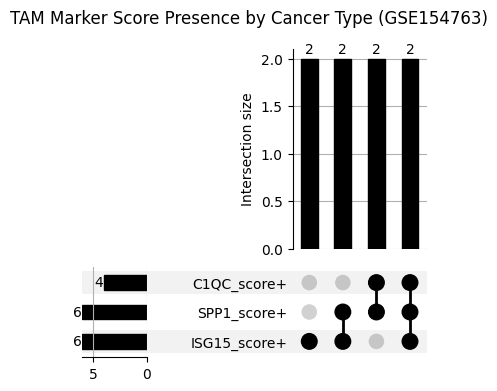

In [30]:
# Upset용 membership 테이블 생성
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

score_name_map = {
    "C1QC_score": "C1QC_score+",
    "SPP1_score": "SPP1_score+",
    "ISG15_score": "ISG15_score+"
}

score_memberships = {}

for cancer, row in score_presence.iterrows():
    present_scores = [
        score_name_map[col]
        for col in score_presence.columns
        if row[col]
    ]
    score_memberships[cancer] = present_scores

print(score_memberships)

data = from_memberships(
    list(score_memberships.values()),
    data=list(score_memberships.keys())
)

upset = UpSet(data, subset_size="count", show_counts=True)
upset.plot()
plt.suptitle("TAM Marker Score Presence by Cancer Type (GSE154763)")
plt.tight_layout()
plt.show()

# A. Annotation-based strict subtype

In [18]:
# 각 암종 별로 C1QC+ TAM, SPP1+ TAM, ISG15+ 비율이 어떻게 다른지 확인

import pandas as pd
import matplotlib.pyplot as plt

composition = (
    adata_mac.obs
    .groupby(['cancer', 'tam_subtype'], observed=True)
    .size()
    .unstack(fill_value=0)
)

composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100
print(composition_pct.round(1))

NameError: name 'adata_mac' is not defined

In [50]:
composition_n = composition.sum(axis=1).rename("n_macrophages")

composition_summary = composition_pct.round(1).copy()
composition_summary["n_macrophages"] = composition_n

display(composition_summary)

tam_subtype,C1QC+ TAM,ISG15+ TAM,Other Macrophage,SPP1+ TAM,n_macrophages
cancer,,,,,
ESCA,22.8,0.0,77.2,0.0,4825
KIDNEY,17.5,0.0,82.5,0.0,8796
LYM,9.9,90.1,0.0,0.0,293
MYE,86.9,0.0,13.1,0.0,1156
OV-FTC,58.7,0.0,0.0,41.3,3278
PAAD,74.2,0.0,0.0,25.8,1379
THCA,13.3,4.3,67.4,15.0,3326
UCEC,20.6,7.6,46.2,25.6,4194


### 결과 분석
암종 별로 패턴이 완전히 다른 것을 알수 있다.

`C1QC+ TAM 우세 (조직 상주 대식세포가 많음)`  
- MYE 86.9%, PAAD 74.2%, OV-FTC 58.7%
- 해당 암종에서는 C1QC-labeled macrophage가 macrophage population 내 주요 subtype으로 관찰되었다.
- 다만 본 분석은 composition 분석이므로 C1QC+ TAM 우세가 실제 예후와 연결되는지는 survival/clinical outcome 데이터 없이는 판단할 수 없다.  

`ISG15+ TAM`  
- LYM 90.1% -> 압도적으로 높다. 림프종 특이적 패턴 확인  
- THCA 4.3%, UCEC 7.6% -> 소량 존재  

`SPP1+ TAM이 strict annotation 기준으로 관찰되지 않은 암종 0인 암종들`  
- ESCA, KIDNEY, LYM, MYE
- 이 암종들에서는 MajorCluster 이름에 SPP1이 포함된 macrophage cluster가 없었다.
- 따라서 annotation-based strict mapping 기준으로는 SPP1+ TAM 비율이 0%로 나타났다.
- 단, Other Macrophage 내부에 SPP1-like 발현 패턴을 보이는 cluster가 존재할 가능성은 marker score 기반으로 별도 확인해야 한다.

> C1QC+ TAM과 SPP1+ TAM은 일부 암종에서 뚜렷하게 관찰되지만, 모든 암종의 macrophage heterogeneity를 두 subtype만으로 설명하기는 어렵다.  

특히 LYM에서는 ISG15+ macrophage가 우세했고, ESCA/KIDNEY/THCA/UCEC에서는 Other Macrophage 비중이 높았다.
이는 GSE127465 폐암 단일 데이터에서 명확하지 않았던 ISG15-associated state가 pan-cancer context에서는 특정 암종에서 강하게 나타날 수 있음을 시사한다.

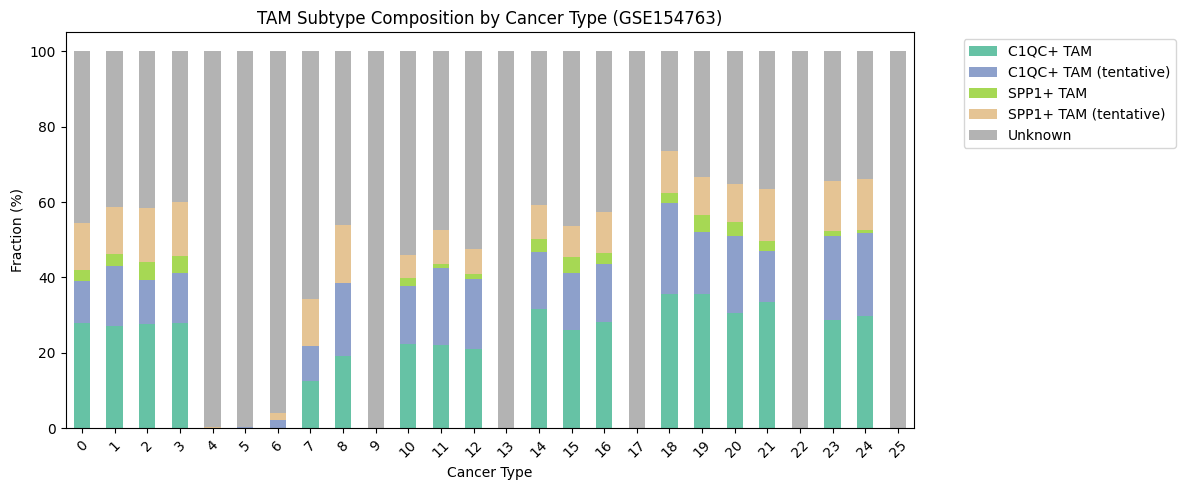

In [17]:
composition_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 5),
    colormap='Set2'
)
plt.title('TAM Subtype Composition by Cancer Type (GSE154763)')
plt.ylabel('Fraction (%)')
plt.xlabel('Cancer Type')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### 그래프 분석

Stacked bar plot을 통해 암종별 macrophage subtype composition의 차이를 시각적으로 확인하였다.

- LYM은 ISG15+ TAM 비율이 90.1%로 가장 높아, 다른 암종과 뚜렷하게 구분되는 패턴을 보였다.
- MYE와 PAAD는 C1QC+ TAM이 우세한 암종으로 나타났다.
- OV-FTC와 PAAD는 C1QC+ TAM과 SPP1+ TAM이 함께 관찰되는 암종이었다.
- ESCA와 KIDNEY는 Other Macrophage 비중이 높아, C1QC/SPP1/ISG15 strict subtype만으로는 macrophage 구성을 충분히 설명하기 어렵다.
- THCA와 UCEC는 C1QC+, SPP1+, ISG15+, Other Macrophage가 모두 관찰되어 상대적으로 heterogeneity가 큰 패턴을 보였다.

이 결과는 폐암 단일 데이터에서 관찰되지 않았던 ISG15+ macrophage population이 pan-cancer 데이터에서는 LYM을 중심으로 명확히 나타남을 보여준다. 따라서 ISG15+ TAM은 모든 암종에서 보편적으로 나타나는 subtype이라기보다, 암종 특이적으로 강하게 나타날 수 있는 macrophage state로 해석하는 것이 적절하다.

> 폐암 단일 데이터에서 뚜렷하지 않았던 ISG15+ macrophage population이 pan-cancer metadata에서는 LYM을 중심으로 명확히 관찰되었다.

따라서 ISG15+ TAM 부재가 모든 암종에 일반화되는 패턴은 아니며, 암종 특이적으로 나타날 수 있음을 확인하였다.

### 결과 분석

Annotation-based strict subtype 기준으로 암종별 macrophage composition을 비교한 결과, TAM subtype 구성은 암종마다 크게 달랐다. 본 비율은 전체 세포 대비 비율이 아니라, 각 암종의 macrophage population 내부에서 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM, Other Macrophage가 차지하는 비율을 의미한다.

C1QC+ TAM은 MYE(86.9%), PAAD(74.2%), OV-FTC(58.7%)에서 우세하게 관찰되었다. 이는 해당 암종의 macrophage population에서 C1QC-labeled macrophage가 주요 subtype으로 존재함을 의미한다. 다만 본 분석은 clinical outcome을 포함하지 않으므로, C1QC+ TAM 우세를 직접적으로 예후와 연결해서 해석할 수는 없다.

ISG15+ TAM은 LYM에서 90.1%로 압도적으로 높았으며, THCA(4.3%)와 UCEC(7.6%)에서도 소량 관찰되었다. 이는 폐암 단일 데이터에서 뚜렷하게 보이지 않았던 ISG15+ macrophage population이 특정 암종, 특히 lymphoma에서 강하게 나타날 수 있음을 보여준다.

SPP1+ TAM은 OV-FTC(41.3%), PAAD(25.8%), UCEC(25.6%), THCA(15.0%)에서 관찰되었다. 반면 ESCA, KIDNEY, LYM, MYE에서는 MajorCluster 이름에 SPP1이 포함된 macrophage cluster가 없어 strict annotation 기준으로 SPP1+ TAM 비율이 0%로 나타났다. 단, 이 암종들의 Other Macrophage 내부에 SPP1-like expression pattern을 보이는 cluster가 존재할 가능성은 marker score 기반으로 별도 확인이 필요하다.

전체적으로 C1QC+ TAM과 SPP1+ TAM은 pan-cancer 수준에서 반복적으로 관찰되지만, 모든 암종의 macrophage heterogeneity를 두 subtype만으로 설명하기는 어렵다. 특히 LYM에서는 ISG15+ macrophage가 지배적이었고, ESCA/KIDNEY/THCA/UCEC에서는 Other Macrophage 비중이 높게 나타났다.

In [52]:
# 저장
adata_mac.write_h5ad(ALL_MAC_H5AD)
print(f'저장 완료: {ALL_MAC_H5AD}')

저장 완료: dataset\GSE154763_all_mac.h5ad


# UpSet Plot진행
: 암종별로 어떤 TAM subtype marker gene이 겹치는지 보는 것
즉 어떤 암종에서 어떤 TAM subtype이 존재하는지 조합을 보는 것

일단 라이브러리를 설치해야한다
pip install upsetplot --break-system-packages

In [53]:
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

adata_mac = sc.read_h5ad(ALL_MAC_H5AD)

cancer_subtypes = {}
for cancer in adata_mac.obs['cancer'].unique():
    subset = adata_mac.obs[adata_mac.obs['cancer'] == cancer]
    subtypes = subset['tam_subtype'].unique().tolist()
    subtypes = [s for s in subtypes if s != 'Other Macrophage']
    cancer_subtypes[cancer] = subtypes

print(cancer_subtypes)

{'ESCA': ['C1QC+ TAM'], 'KIDNEY': ['C1QC+ TAM'], 'LYM': ['ISG15+ TAM', 'C1QC+ TAM'], 'MYE': ['C1QC+ TAM'], 'OV-FTC': ['C1QC+ TAM', 'SPP1+ TAM'], 'PAAD': ['SPP1+ TAM', 'C1QC+ TAM'], 'THCA': ['C1QC+ TAM', 'ISG15+ TAM', 'SPP1+ TAM'], 'UCEC': ['ISG15+ TAM', 'C1QC+ TAM', 'SPP1+ TAM']}


c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\upsetplot\data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(

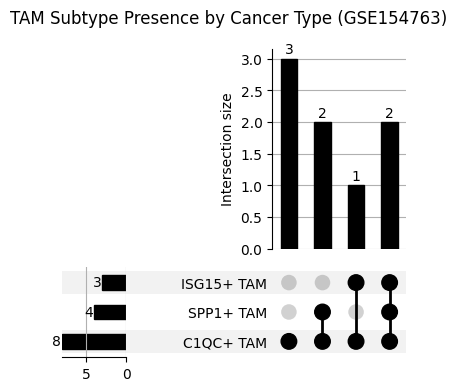

In [54]:
from upsetplot import UpSet, from_memberships

memberships = list(cancer_subtypes.values())
labels = list(cancer_subtypes.keys())

data = from_memberships(memberships, data=labels)

upset = UpSet(data, subset_size='count', show_counts=True)
upset.plot()
plt.suptitle('TAM Subtype Presence by Cancer Type (GSE154763)')
plt.tight_layout()
plt.show()

### UpSet plot 해석법

왼쪽 가로 막대(Set Size):
- C1QC+ TAM: 8개 암종 모두 존재
- SPP1+ TAM: 4개 암종
- ISG15+ TAM: 3개 암종
위쪽 세로 막대 + 아래 점 조합(Intersection):
- 점 하나만 채워진 것 -> 그 서브타입만 단독으로 있는 암종 수
- 점 여러개 연결된 것 -> 그 조합이 같이 있는 암종 수

result
- C1QC+ 단독 (점 하나) -> 3개 암종 (ESCA, KIDNEY, MYE)
- C1QC+ + SPP1+ 조합 -> 2개 암종 (OV-FTC, PAAD)
- C1QC+ + SPP1+ + ISG15+ 조합 -> 2개 암종 (THCA, UCEC)
- C1QC+ + ISG15+ 조합 -> 1개 암종 (LYM)